# Limit contours: event list → excluded $(m_\text{DM}, \alpha_n)$ regions

**Private.** Successor to `12_limit_atmos`, with the limit set by the public
[`optimum_interval`](https://github.com/tunnell/optimum_interval) package
instead of the $\langle N\rangle = 3$ rule, so observed candidate events are
handled without a background model.

**Input:** the `EVENTS` array of reconstructed kick momenta (here one random
toy candidate). *Replacing that array with data is the only change needed to
run the real analysis.* **Output:** the 95% CL excluded
$(m_\text{DM}, \alpha_n)$ regions for the **seven planned mediator ranges**,

$$\lambda = 2\ \text{m},\ 2\ \text{cm},\ 2\ \text{mm},\ 200\ \text{µm},\
20\ \text{µm},\ 2\ \text{µm},\ 0.2\ \text{µm}$$

($\xi \equiv R_\text{eff}/\lambda$ from $10^{-3}$ to $10^{3}$, sensor radius
$R_\text{eff}$ = 200 µm), plus the machine-readable `limit_contour_data.npz`.
Couplings run up to $\alpha_n = 1$ and masses up to the Planck mass.

The notebook is a pipeline, one section each:

1. **Physics model**: SHM halo at the top of the atmosphere (`luhdm.halo`);
   attenuation ODE → detector-frame $f(v)$ carrying the survival fraction
   (`luhdm.atmosphere`); classical $K_1$-impulse cross section from a
   finite-range Yukawa on the finite-size magnet (`luhdm.cross_section`; the
   two shortest ranges use its log-space variant, since $K_1(\xi)$ underflows
   float64 past $\xi \approx 700$); assembled into
   $dR/dq = n_\text{DM}\int f(v)\,v\,(d\sigma/dq)\,dv$ by
   `differential_rate_trapz` *in this notebook*; it is the formula you tweak.
2. **Statistics**: at each $(m_\text{DM}, \alpha_n)$ grid point, the expected
   count $\mu$ and normalized spectrum shape feed the optimum-interval
   **extremeness** (`luhdm.limits`). Because the spectrum shape itself depends
   on the coupling (finite range, attenuation), the limit is a **level set of
   the extremeness surface**, not a single $\mu$ solve.
3. **Results**: the extremeness surface at the reference range
   $\lambda = R_\text{eff}$, then all seven 95% contours.
4. **Understanding**: why the islands look the way they do, plus
   transit-count and reach maps up to the Planck mass. *Pedagogical: nothing
   there feeds the limit.*
5. **Output**: `limit_contour_data.npz`: grids, surfaces, contour polylines.
6. **Appendix**: validation against closed forms and spot checks along the
   reference contour.


In [1]:
%matplotlib inline
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from luhdm import atmosphere, config, cross_section, halo, limits, units

R_eff = config.R_EFF             # 200 um
Q_THRESH = config.Q_THRESH
T_TOTAL = 3600 * 24 * 7 * 2      # 2 weeks in seconds
CONFIDENCE = 0.95
M_PLANCK = 1.22e19               # GeV

# the seven planned mediator ranges, largest first: (tag, lambda [m], color)
LAMBDAS = [
    ("2m", 2.0, "#1f77b4"),
    ("2cm", 2e-2, "#ff7f0e"),
    ("2mm", 2e-3, "#2ca02c"),
    ("200um", 2e-4, "#d62728"),
    ("20um", 2e-5, "#9467bd"),
    ("2um", 2e-6, "#8c564b"),
    ("0p2um", 2e-7, "#e377c2"),
]
LAMB_REF = 2e-4                  # reference range for the detailed figures

def lamb_label(lamb_m):
    # mediator range in SI and natural units, for plot labels
    x = units.conv_m2pGeV(lamb_m)
    e = int(np.floor(np.log10(x)))
    if lamb_m >= 1:
        si = f"{lamb_m:.0f} m"
    elif lamb_m >= 1e-2:
        si = f"{lamb_m * 1e2:.0f} cm"
    elif lamb_m >= 1e-3:
        si = f"{lamb_m * 1e3:.0f} mm"
    else:
        si = f"{lamb_m * 1e6:.3g} µm"
    return rf"$\lambda$ = {si} = ${x / 10**e:.1f}\times10^{{{e}}}$ GeV$^{{-1}}$"


np.random.seed(20260702)         # luhdm samplers use legacy np.random
print(f"N_n = {config.N_NEUTRONS:.2e}   q_th = {Q_THRESH:.0f} GeV   "
      f"R_eff = {R_eff * 1e6:.0f} um")

N_n = 2.51e+20   q_th = 8400 GeV   R_eff = 200 um


## Input: the event list

One candidate kick drawn at random just above threshold. **Replace this array
with the reconstructed kicks from data and rerun; nothing else changes.**


In [2]:
rng = np.random.default_rng(20260702)
EVENTS = 10 ** rng.uniform(np.log10(Q_THRESH), np.log10(3 * Q_THRESH), size=1)
print(f"observed kicks [GeV]: {np.round(EVENTS, 1)}")

observed kicks [GeV]: [12625.]


## Physics model

### Cross-section interpolants

One tabulation of the dimensionless $d\sigma/d\tilde q$ per mediator range.
For $\xi = R_\text{eff}/\lambda \le 30$ this is Dorian's direct tabulation;
beyond that the direct Bessels degrade and then underflow
($K_1(1000) = 0$ in float64), so the two shortest ranges use the package's
log-space variant (`make_ln_dsigma_dq_interpolant` / `dsigma_dq_ln`),
validated against the direct code in `tests/test_cross_section_ln.py`.


In [3]:
import os
os.environ["TQDM_DISABLE"] = "1"

XSEC = {}
for tag, lamb, color in LAMBDAS:
    xi = R_eff / lamb
    use_ln = xi > 30
    t0 = time.time()
    if use_ln:
        interp = cross_section.make_ln_dsigma_dq_interpolant(R_eff, lamb)
    else:
        interp = cross_section.make_dsigma_dq_interpolant(
            1e-25, R_eff, lamb, N_points=600)
    XSEC[tag] = dict(lamb=lamb, color=color, use_ln=use_ln, interp=interp)
    print(f"{tag:>6}: xi = {xi:8.3f}  {'log-space' if use_ln else 'direct':>9}"
          f"  ({time.time() - t0:.0f}s)")

def dsigma_dq_any(q, alpha, vs, xs):
    # dispatch to the direct or log-space evaluator for this range
    fn = cross_section.dsigma_dq_ln if xs["use_ln"] else cross_section.dsigma_dq
    return fn(q, alpha, xs["lamb"], R_eff, vs, xs["interp"])

  0%|          | 0/600 [00:00<?, ?it/s]

~/code/luhdm/luhdm/cross_section.py:302: IntegrationWarning: The maximum number of subdivisions (100) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  result, _ = quad(integrand, 0, t_max, limit=100)
~/code/luhdm/luhdm/cross_section.py:302: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  result, _ = quad(integrand, 0, t_max, limit=100)
  0%|          | 2/600 [00:00<00:32, 18.63it/s]

  1%|          | 4/600 [00:00<00:32, 18.47it/s]

  1%|          | 6/600 [00:00<00:31, 18.58it/s]

  1%|▏         | 8/600 [00:00<00:37, 15.85it/s]

...

 98%|█████████▊| 585/600 [00:16<00:00, 53.50it/s]

 98%|█████████▊| 591/600 [00:16<00:00, 49.57it/s]

100%|█████████▉| 597/600 [00:16<00:00, 46.43it/s]

100%|██████████| 600/600 [00:16<00:00, 36.05it/s]

  20um: xi =   10.000     direct  (17s)
   2um: xi =  100.000  log-space  (0s)
 0p2um: xi = 1000.000  log-space  (0s)


### Differential rate: the physics to tweak

Same formula and notation as `12_limit_atmos` (`mu` is the DM mass in the
original notation); only the rate conversion constant moved to `luhdm.units`.
`expected_transits` (used in the Understanding section and the appendix) is
the companion flux integral: the number of particles passing within the
threshold reach $b_\text{max}$ during the exposure.


In [4]:
def differential_rate_trapz(qs, alpha_n, mu, f_v_f, xs):
    '''dR/dq via trapz (mu = m_DM in the original notation).'''
    alpha = alpha_n * config.N_NEUTRONS
    n_dm = halo.number_density_dm(mu)

    # Precompute f_vf on a fixed grid spanning all v_mins
    v_min_global = qs.min() / mu
    vs_global = np.geomspace(v_min_global, config.VESC, 500)
    f_vf_grid = f_v_f(vs_global)  # KDE evaluated once

    results = []
    for q in qs:
        mask = vs_global >= q / mu
        vs = vs_global[mask]
        integrand = n_dm * f_vf_grid[mask] * vs * dsigma_dq_any(q, alpha, vs, xs)
        results.append(np.trapezoid(integrand, vs) * units.CONV2RATE)

    return np.maximum(np.array(results), 0)


v_i_samples = atmosphere.sample_shm(int(1e5))  # SHM at the top of the atmosphere


def expected_transits(alpha_n, mu, f_v_f, xs):
    # expected flybys within the threshold reach during the exposure (mu = m_DM)
    alpha = alpha_n * config.N_NEUTRONS
    vs = np.geomspace(max(Q_THRESH / mu, 1e-8), config.VESC, 300)
    b_max = (cross_section.impact_parameter_max_ln if xs["use_ln"]
             else cross_section.impact_parameter_max)
    b = b_max(Q_THRESH, alpha, xs["lamb"], R_eff, vs)
    n_m3 = 0.3 / mu * 1e6  # rho = 0.3 GeV/cm^3 -> 1/m^3
    return T_TOTAL * np.trapezoid(
        f_v_f(vs) * n_m3 * (vs * units.C_M_S) * np.pi * b**2, vs)

### Spectra

The attenuated $dR/dq$ for all seven ranges at a fixed mass and coupling. At
fixed coupling the spectrum weakens and steepens as the range shrinks (the
momentum cap $\tilde q < K_1(\xi)$ bites); the longest ranges are effectively
massless, with the endpoint at the halo kinematic limit.


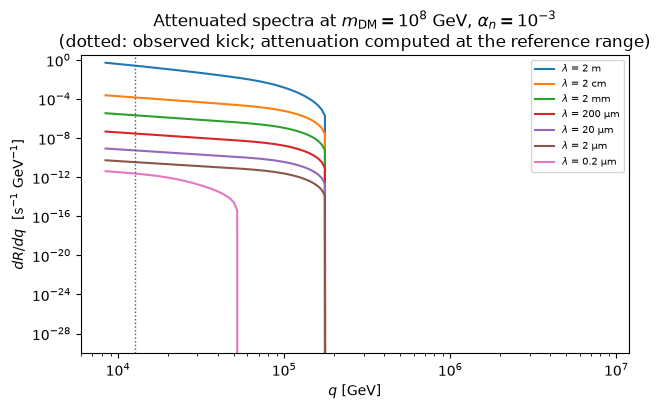

In [5]:
ALPHA_N_SHOW = 1e-3
M_SHOW = 1e8
qs_plot = np.geomspace(Q_THRESH, 1000 * Q_THRESH, 160)

v_min_show = qs_plot.min() / M_SHOW / 10
v_f_show = atmosphere.compute_v_f_distribution(
    ALPHA_N_SHOW, LAMB_REF, M_SHOW, v_i_samples, v_min=v_min_show, n_grid=80)
f_v_f_show = atmosphere.compute_f_vf(v_f_show, v_min_show)[0]

fig, ax = plt.subplots(figsize=(6.5, 4.2))
for tag, lamb, color in LAMBDAS:
    ax.loglog(qs_plot,
              differential_rate_trapz(qs_plot, ALPHA_N_SHOW, M_SHOW,
                                      f_v_f_show, XSEC[tag]),
              color=color, label=lamb_label(lamb).split(" = $")[0])
for q_ev in EVENTS:
    ax.axvline(q_ev, color="#555555", lw=1, ls=":")
ax.set_ylim(bottom=1e-30)
ax.set_xlabel(r"$q$ [GeV]")
ax.set_ylabel(r"$dR/dq$  [s$^{-1}$ GeV$^{-1}$]")
ax.set_title(rf"Attenuated spectra at $m_{{\rm DM}} = 10^8$ GeV, "
             rf"$\alpha_n = 10^{{-3}}$" + "\n(dotted: observed kick; "
             "attenuation computed at the reference range)")
ax.legend(fontsize=7)
fig.tight_layout()

## Statistics: what the extremeness means

At each grid point the extremeness is

$$p = \Pr\big(C_\text{max}^\text{pseudo} < C_\text{max}^\text{obs}\,\big|\,m_\text{DM}, \alpha_n,\ \text{no background}\big),$$

the fraction of background-free pseudo-experiments generated *under that
hypothesis* whose most-anomalously-empty spectral stretch looks **less** empty
than the data. Physically: $p = 0.95$ means the hypothesis predicts enough
events that 95% of the time our gaps would have been filled in more than they
are: the observed emptiness sits in the 5% tail, so the point is excluded at
95% CL. The surface *is* the confidence level: the rule "exclude where
$p \ge C$" wrongly rejects a true hypothesis at most $(1-C)$ of the time
(frequentist coverage, not a posterior probability), and any CL is a level set
of the same array; the 90% contour needs no rescan. The test is one-sided by
construction: background can only *add* events, filling gaps and lowering $p$,
so backgrounds can weaken an exclusion but never fake one.


## The $(m_\text{DM}, \alpha_n)$ scans

One scan per mediator range, from `scripts/scan_grid.py` run on a many-core
node (`--lamb <meters> --out scan7_<tag>.npz`); each stores three surfaces:
`counts` (expected events $\mu$), `extremeness`, and `n_transit`. Monte-Carlo
calibration tables are shared across the plane via $\mu$ rounding. If a scan
file is missing, a coarse inline scan runs for the reference range only.


In [6]:
SCANS = {}
for tag, lamb, color in LAMBDAS:
    f = Path(f"scan7_{tag}.npz")
    if not f.exists():
        print(f"{f} missing; skipping {tag}")
        continue
    d = np.load(f)
    assert np.allclose(d["events"], EVENTS), f"{f}: different event list!"
    assert np.isclose(float(d["lamb"]), lamb), f"{f}: lambda mismatch"
    SCANS[tag] = dict(
        ms=d["ms"], alphas_n=d["alphas_n"], extremeness=d["extremeness"],
        counts=d["counts"], n_transit=np.maximum(d["n_transit"], 0.0),
        lamb=lamb, color=color)
    # (n_transit clip: the KDE tail can oscillate slightly negative below the
    # kinematic floor)
print(f"loaded {len(SCANS)}/{len(LAMBDAS)} scans")

REF_TAG = "200um"
if REF_TAG not in SCANS:
    # coarse inline fallback for the reference range
    ms = np.logspace(6.6, np.log10(M_PLANCK), 19)
    alphas_n = np.logspace(-8.5, 0.0, 30)
    counts = np.zeros((alphas_n.size, ms.size))
    extremeness = np.zeros((alphas_n.size, ms.size))
    N_T = np.zeros((alphas_n.size, ms.size))
    table = limits.new_table(seed=20260702)
    xs_ref = XSEC[REF_TAG]
    t0 = time.time()
    for im, m in enumerate(ms):
        for ia, alpha_n in enumerate(alphas_n):
            v_min = Q_THRESH / m / 10
            v_f_samples = atmosphere.compute_v_f_distribution(
                alpha_n, LAMB_REF, m, v_i_samples, v_min=v_min, n_grid=80)
            f_v_f = atmosphere.compute_f_vf(v_f_samples, v_min)[0]
            qs = np.geomspace(Q_THRESH, 1e4 * Q_THRESH, 200)
            diff_rate = differential_rate_trapz(qs, alpha_n, m, f_v_f, xs_ref)
            extremeness[ia, im], counts[ia, im] = limits.extremeness_and_mu(
                table, EVENTS, qs, diff_rate, T_TOTAL)
            N_T[ia, im] = expected_transits(alpha_n, m, f_v_f, xs_ref)
    SCANS[REF_TAG] = dict(ms=ms, alphas_n=alphas_n, extremeness=extremeness,
                          counts=counts, n_transit=N_T, lamb=LAMB_REF,
                          color="#d62728")
    print(f"inline scan ({REF_TAG}): {time.time() - t0:.0f}s")

REF = SCANS[REF_TAG]

loaded 7/7 scans


## Results

### The reference range, $\lambda = R_\text{eff}$ = 200 µm

Solid: the 95% CL optimum-interval contour given `EVENTS`. Dashed: the
$\langle N\rangle = 3$ zero-event contour (the old rule) from the same
`counts` surface. The excluded region is an island; each edge is explained in
"Understanding" below.

Note the dashed contour pokes out past the red one near the floor and the
left edge: there the (narrow) kinematic window contains the observed kick, so
the honest one-event limit is weaker than the zero-event rule, which simply
does not apply once there is a candidate. Where the window excludes the event
the two coincide.


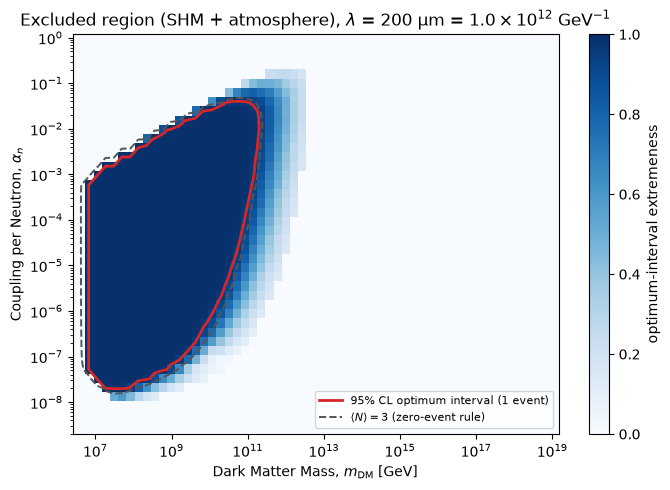

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
mesh = ax.pcolormesh(REF["ms"], REF["alphas_n"], REF["extremeness"],
                     cmap="Blues", vmin=0, vmax=1, shading="auto")
fig.colorbar(mesh, ax=ax, label="optimum-interval extremeness")
cs95 = ax.contour(REF["ms"], REF["alphas_n"], REF["extremeness"],
                  levels=[CONFIDENCE], colors="#d62728", linewidths=2)
cs3 = ax.contour(REF["ms"], REF["alphas_n"], REF["counts"], levels=[3.0],
                 colors="#555555", linewidths=1.4, linestyles="--")
ax.plot([], [], color="#d62728", lw=2,
        label=f"{CONFIDENCE:.0%} CL optimum interval ({EVENTS.size} event)")
ax.plot([], [], color="#555555", lw=1.4, ls="--",
        label=r"$\langle N\rangle = 3$ (zero-event rule)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Dark Matter Mass, $m_{\rm DM}$ [GeV]")
ax.set_ylabel(r"Coupling per Neutron, $\alpha_n$")
ax.set_title("Excluded region (SHM + atmosphere), " + lamb_label(LAMB_REF))
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
fig.savefig("limit_contour.png", dpi=140)

### All seven ranges

The 95% CL contours for the seven planned ranges, with the single toy
candidate and atmospheric attenuation everywhere. Five ranges exclude; the
momentum cap $\tilde q_\text{max} = K_1(\xi)$ organizes the family:

- **Shared floor at long range.** The 2 m, 2 cm, and 2 mm islands share the
  same coupling floor, $\alpha_n \approx 1.3\times10^{-8}$ (Coulomb regime);
  200 µm and 20 µm pay the cap penalty ($2.0\times10^{-8}$ and
  $5.3\times10^{-7}$).
- **High-mass endpoints ladder by $\sim100\times$ per decade of $\lambda$**
  (reach saturation, $\sigma_\text{sat} \sim \lambda^2$, vs the $1/m$ number
  density): $1.6\times10^{9}$ GeV (20 µm), $1.4\times10^{11}$ (200 µm),
  $1.9\times10^{13}$ (2 mm), $1.6\times10^{15}$ (2 cm), $7.4\times10^{18}$
  (2 m). Even the 2 m island closes just below the Planck mass.
- **The two shortest ranges exclude nothing.** At 2 µm the attenuated rate
  saturates at $\mu \approx 3.8$ and the extremeness peaks at 0.84, below
  95%; in vacuum this case would sit exactly at the knife edge, and the
  atmosphere tips it under by preferentially stopping the slow particles that
  carry the largest finite-range kicks. At 0.2 µm ($\xi = 1000$)
  $\mu \le 0.06$ everywhere: no exclusion at any coupling up to
  $\alpha_n = 1$. Both are honest nulls, not plotting gaps.


    2m: m in [6.8e+06, 7.4e+18] GeV, alpha_n down to 1.3e-08
   2cm: m in [6.8e+06, 1.6e+15] GeV, alpha_n down to 1.3e-08
   2mm: m in [6.8e+06, 1.9e+13] GeV, alpha_n down to 1.3e-08
 200um: m in [6.8e+06, 1.4e+11] GeV, alpha_n down to 2.0e-08
  20um: m in [6.8e+06, 1.6e+09] GeV, alpha_n down to 5.3e-07
   2um: no exclusion (max p = 0.84, max mu = 3.76)
 0p2um: no exclusion (max p = 0.00, max mu = 0.06)


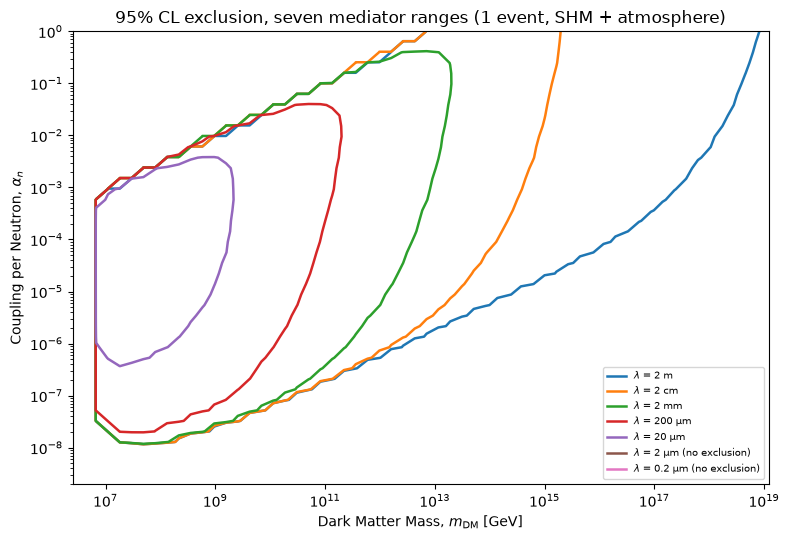

In [8]:
fig, ax = plt.subplots(figsize=(8, 5.5))
CS95 = {}
for tag, lamb, color in LAMBDAS:
    if tag not in SCANS:
        continue
    s = SCANS[tag]
    if (s["extremeness"] >= CONFIDENCE).any():
        CS95[tag] = ax.contour(s["ms"], s["alphas_n"], s["extremeness"],
                               levels=[CONFIDENCE], colors=color,
                               linewidths=1.8)
        ax.plot([], [], color=color, lw=1.8,
                label=lamb_label(lamb).split(" = $")[0])
    else:
        ax.plot([], [], color=color, lw=1.8,
                label=lamb_label(lamb).split(" = $")[0] + " (no exclusion)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(REF["ms"].min(), M_PLANCK)
ax.set_ylim(REF["alphas_n"].min(), 1.0)
ax.set_xlabel(r"Dark Matter Mass, $m_{\rm DM}$ [GeV]")
ax.set_ylabel(r"Coupling per Neutron, $\alpha_n$")
ax.set_title(f"{CONFIDENCE:.0%} CL exclusion, seven mediator ranges "
             f"({EVENTS.size} event, SHM + atmosphere)")
ax.legend(loc="lower right", fontsize=7)
fig.tight_layout()
fig.savefig("limit_contour_all.png", dpi=140)

for tag, lamb, color in LAMBDAS:
    if tag not in SCANS:
        continue
    s = SCANS[tag]
    excl = s["extremeness"] >= CONFIDENCE
    if excl.any():
        m_ex = np.broadcast_to(s["ms"], excl.shape)[excl]
        a_ex = np.broadcast_to(s["alphas_n"][:, None], excl.shape)[excl]
        print(f"{tag:>6}: m in [{m_ex.min():.1e}, {m_ex.max():.1e}] GeV, "
              f"alpha_n down to {a_ex.min():.1e}")
    else:
        print(f"{tag:>6}: no exclusion (max p = {s['extremeness'].max():.2f}, "
              f"max mu = {s['counts'].max():.2f})")

## Understanding the islands

*Everything in this section is pedagogical; none of it feeds the limit.*
Every edge has a one-line explanation (scalings at fixed exposure):

- **Left edge (kinematic floor).** Below
  $m = q_\text{th}/v_\text{esc} \approx 4.6\times10^6$ GeV even an
  escape-velocity particle cannot deliver the threshold kick, at any coupling.
- **Bottom edge (statistics floor).** The smallest coupling with
  $\mu \gtrsim 3$ expected events. The rate scales as
  $\alpha^2 n_\text{DM} \propto \alpha^2/m$, so the floor rises as
  $\alpha_\text{min} \propto \sqrt{m}$. Ranges with $\lambda \gtrsim$ mm share
  the same floor (Coulomb regime); shorter ranges pay the momentum-cap
  penalty, $\tilde q_\text{max} = K_1(\xi)$.
- **Top edge (atmospheric ceiling).** Stopping power also scales as
  $\alpha^2/m$: above the ceiling particles arrive below threshold speed, so
  the ceiling rises $\propto \sqrt{m}$ (up to a Coulomb log).
- **Right edge (reach saturation).** Once the impact parameters needed for a
  kick exceed $\lambda$, the reach grows only as $\lambda\ln\alpha$, the
  cross section saturates at $\sim\lambda^2$, and the falling number density
  $1/m$ wins: each factor of 10 in $\lambda$ buys roughly a factor of 100 in
  mass reach. No finite range reaches the Planck mass; only an exactly
  massless mediator (Coulomb reach $\propto \alpha$, unbounded) keeps the
  band open, as the maps below show.

The maps below make these statements visible for the reference range.


### Transit-count and reach maps up to the Planck mass

**Top row:** color is $\log_{10} N_t$, the expected number of particles passing
within $\pi b_\text{max}^2$ during the exposure (halo flux, no attenuation;
the atmosphere only matters near the low-mass ceiling). White solid: $N_t = 1$;
white dashed: $N_t = 3$; red: the 95% exclusion contour from the scan. The
finite-range $N_t = 1$ boundary is a near-vertical wall (saturating reach);
a truly massless mediator's boundary is a $\sqrt{m}$ diagonal that continues
to the Planck mass.

**Bottom row:** the flux-averaged threshold reach
$b_\text{max} = \sqrt{\langle b^2 \rangle}$ in meters, with contours at
everyday length scales. This is the aperture that converts flux into transits,
$N_t = \Phi \cdot \pi b_\text{max}^2 \cdot T$: for the massless mediator the
*formal* reach at large coupling is macroscopic
($b_\text{max} = 2\alpha/(q_\text{th} v)$), so flux quantization alone never
closes the band; the finite-range reach saturates near
$R_\text{eff} + \mathcal{O}(10)\lambda$, which is why its $N_t = 1$ wall is
real. Capping the massless reach at a laboratory scale $b_\text{cap}$ would
turn the falling flux into a hard, coupling-independent endpoint at
$m_\text{end} = \rho\,\bar v\,\pi b_\text{cap}^2\,T \approx
2.5\times10^{15}\ \text{GeV} \times (b_\text{cap}/10\,\text{cm})^2\,
(T/2\,\text{wk})$.


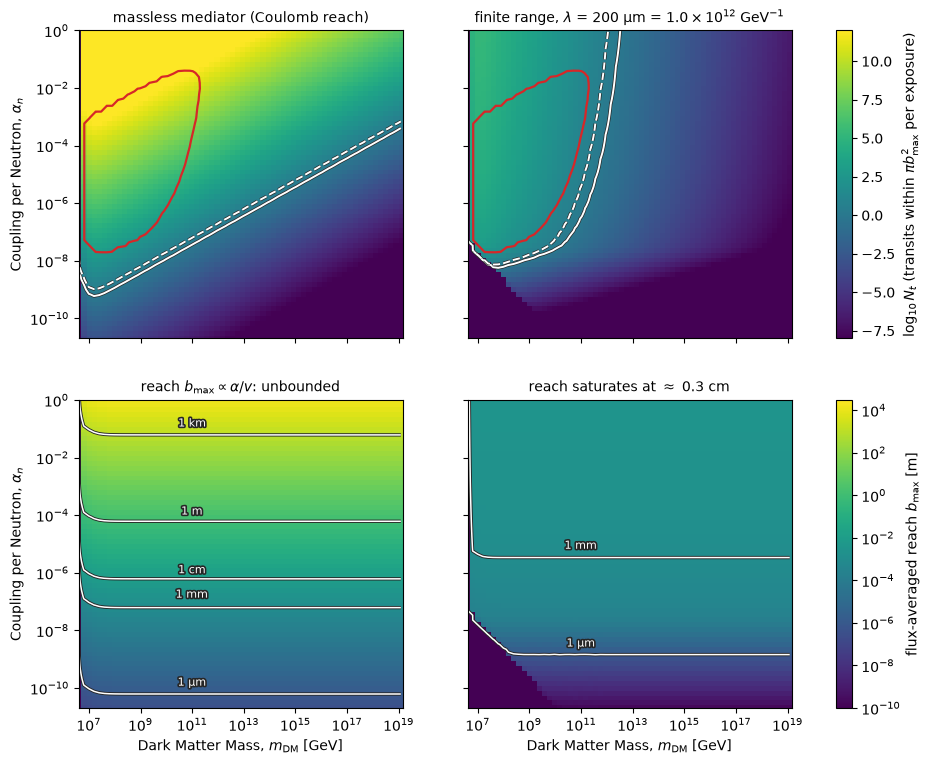

In [9]:
HBAR_C_M = 1.9733e-16  # GeV^-1 in meters

def transit_count_halo(m, alpha_n, xs=None):
    # (N_t, flux-averaged pi*b_max^2 [m^2]) for the unattenuated halo flux;
    # xs=None -> massless (analytic Coulomb reach)
    vs = np.geomspace(max(Q_THRESH / m, 1e-8), config.VESC, 200)
    if vs.size < 2 or vs[0] >= config.VESC:
        return 0.0, 0.0
    alpha = alpha_n * config.N_NEUTRONS
    if xs is None:
        b = 2 * alpha / (Q_THRESH * vs) * HBAR_C_M
    else:
        b_max = (cross_section.impact_parameter_max_ln if xs["use_ln"]
                 else cross_section.impact_parameter_max)
        b = b_max(Q_THRESH, alpha, xs["lamb"], R_eff, vs)
    flux_w = halo.standard_halo_model(vs) * (vs * units.C_M_S)
    area = np.pi * b**2
    n_m3 = 0.3 / m * 1e6
    nt = T_TOTAL * n_m3 * np.trapezoid(flux_w * area, vs)
    a_eff = np.trapezoid(flux_w * area, vs) / np.trapezoid(flux_w, vs)
    return nt, a_eff

ms_map = np.geomspace(4e6, M_PLANCK, 64)
al_map = np.geomspace(2e-11, 1.0, 64)

def grids(xs):
    out = np.array([[transit_count_halo(m, a, xs) for m in ms_map]
                    for a in al_map])
    return out[:, :, 0], out[:, :, 1]

NT_ML_MAP, AEFF_ML_MAP = grids(None)
NT_FR_MAP, AEFF_FR_MAP = grids(XSEC[REF_TAG])
B_ML_MAP = np.sqrt(AEFF_ML_MAP / np.pi)  # flux-averaged reach [m]
B_FR_MAP = np.sqrt(AEFF_FR_MAP / np.pi)

import matplotlib.patheffects as pe
from matplotlib.colors import LogNorm, Normalize

def outline(artists):  # keep white lines/labels legible on any viridis shade
    for a in artists:
        a.set_path_effects([pe.Stroke(linewidth=2.4, foreground="0.15"),
                            pe.Normal()])

fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.8), sharex=True, sharey=True)
norm_nt = Normalize(vmin=-8, vmax=12)
norm_b = LogNorm(vmin=1e-10, vmax=3e4)
B_LEVELS = [1e-6, 1e-3, 1e-2, 1.0, 1e3]
B_NAMES = {1e-6: "1 µm", 1e-3: "1 mm", 1e-2: "1 cm", 1.0: "1 m", 1e3: "1 km"}
titles = ["massless mediator (Coulomb reach)",
          "finite range, " + lamb_label(LAMB_REF)]

for j, (NT_MAP, B_MAP) in enumerate([(NT_ML_MAP, B_ML_MAP),
                                     (NT_FR_MAP, B_FR_MAP)]):
    ax = axes[0, j]
    z = np.log10(np.clip(NT_MAP, 1e-8, 1e12))
    mesh_nt = ax.pcolormesh(ms_map, al_map, z, cmap="viridis", norm=norm_nt,
                            shading="auto")
    for lev, ls in [(1.0, "-"), (3.0, "--")]:
        cs = ax.contour(ms_map, al_map, NT_MAP, levels=[lev], colors="w",
                        linewidths=1.4, linestyles=ls)
        outline(getattr(cs, "collections", [cs]))
    ax.set_title(titles[j], fontsize=10)

    ax = axes[1, j]
    mesh_b = ax.pcolormesh(ms_map, al_map, np.clip(B_MAP, 1e-10, None),
                           cmap="viridis", norm=norm_b, shading="auto")
    cs = ax.contour(ms_map, al_map, B_MAP, levels=B_LEVELS, colors="w",
                    linewidths=1.1)
    outline(getattr(cs, "collections", [cs]))
    # label each level just above its line, mid-plot (the lines are
    # horizontal away from the kinematic floor)
    col = np.argmin(np.abs(ms_map - 1e11))
    for lev in cs.levels:
        miss = np.abs(np.log10(B_MAP[:, col] / lev))
        if miss.min() < 0.3:
            y = al_map[miss.argmin()]
            txt = ax.text(1e11, y * 1.5, B_NAMES[lev], fontsize=8, color="w",
                          ha="center", va="bottom")
            outline([txt])
    note = (r"reach $b_{\rm max} \propto \alpha/v$: unbounded" if j == 0 else
            rf"reach saturates at $\approx$ {B_MAP.max() * 100:.1f} cm")
    ax.set_title(note, fontsize=10)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"Dark Matter Mass, $m_{\rm DM}$ [GeV]")

# overlay the reference 95% contour on both N_t panels
for j in (0, 1):
    axes[0, j].contour(REF["ms"], REF["alphas_n"], REF["extremeness"],
                       levels=[CONFIDENCE], colors="#d62728", linewidths=1.6)

for ax in axes[:, 0]:
    ax.set_ylabel(r"Coupling per Neutron, $\alpha_n$")
axes[0, 0].set_ylim(al_map[0], 1.0)
fig.colorbar(mesh_nt, ax=axes[0, :], label=r"$\log_{10} N_t$ (transits within "
                                           r"$\pi b_{\rm max}^2$ per exposure)")
fig.colorbar(mesh_b, ax=axes[1, :],
             label=r"flux-averaged reach $b_{\rm max}$ [m]")
fig.savefig("flux_map.png", dpi=140, bbox_inches="tight")

## Machine-readable output

Everything on the plots, written to `limit_contour_data.npz` so nobody ever
has to digitize a figure: per-range grids and surfaces (keys suffixed by the
range tag), the event list, the 95% contours as NaN-separated
(m, alpha_n) polylines, and the Planck-range understanding maps.


In [10]:
def contour_polyline(cs):
    # all segments of a single-level contour as one NaN-separated (N, 2) array
    parts = []
    for seg in cs.allsegs[0]:
        parts.append(seg)
        parts.append(np.full((1, 2), np.nan))
    return np.vstack(parts) if parts else np.empty((0, 2))


out = dict(events=EVENTS, t_total=T_TOTAL, confidence=CONFIDENCE,
           lambdas=np.array([l for _, l, _ in LAMBDAS]))
for tag, lamb, color in LAMBDAS:
    if tag not in SCANS:
        continue
    s = SCANS[tag]
    out[f"ms_{tag}"] = s["ms"]
    out[f"alphas_n_{tag}"] = s["alphas_n"]
    out[f"extremeness_{tag}"] = s["extremeness"]
    out[f"counts_{tag}"] = s["counts"]
    out[f"n_transit_{tag}"] = s["n_transit"]
    if tag in CS95:
        out[f"contour_95_{tag}"] = contour_polyline(CS95[tag])
out["contour_n3_200um"] = contour_polyline(cs3)
out["nt_map_ms"] = ms_map
out["nt_map_alphas"] = al_map
out["nt_map_massless"] = NT_ML_MAP
out["nt_map_finite"] = NT_FR_MAP
out["nt_map_area_massless"] = AEFF_ML_MAP
out["nt_map_area_finite"] = AEFF_FR_MAP
np.savez("limit_contour_data.npz", **out)
d = np.load("limit_contour_data.npz")
print("limit_contour_data.npz:", len(d.files), "arrays")
print(sorted(d.files))

limit_contour_data.npz: 51 arrays
['alphas_n_0p2um', 'alphas_n_200um', 'alphas_n_20um', 'alphas_n_2cm', 'alphas_n_2m', 'alphas_n_2mm', 'alphas_n_2um', 'confidence', 'contour_95_200um', 'contour_95_20um', 'contour_95_2cm', 'contour_95_2m', 'contour_95_2mm', 'contour_n3_200um', 'counts_0p2um', 'counts_200um', 'counts_20um', 'counts_2cm', 'counts_2m', 'counts_2mm', 'counts_2um', 'events', 'extremeness_0p2um', 'extremeness_200um', 'extremeness_20um', 'extremeness_2cm', 'extremeness_2m', 'extremeness_2mm', 'extremeness_2um', 'lambdas', 'ms_0p2um', 'ms_200um', 'ms_20um', 'ms_2cm', 'ms_2m', 'ms_2mm', 'ms_2um', 'n_transit_0p2um', 'n_transit_200um', 'n_transit_20um', 'n_transit_2cm', 'n_transit_2m', 'n_transit_2mm', 'n_transit_2um', 'nt_map_alphas', 'nt_map_area_finite', 'nt_map_area_massless', 'nt_map_finite', 'nt_map_massless', 'nt_map_ms', 't_total']


## Appendix: validation checks

1. **$K_1$ → Coulomb convergence.** At $\lambda$ = 2 m and small coupling
   (threshold kicks come from close flybys, $b \ll \lambda$, the Coulomb
   regime), the tabulated $K_1$ machinery must reproduce the closed form
   $2\pi\alpha^2/(v^2 q^3)$. The ratios below should be $\approx 1$.
2. **Log-space vs direct.** The two shortest ranges use the log-space
   tabulation; `tests/test_cross_section_ln.py` pins agreement with Dorian's
   direct code at the percent level wherever both are healthy
   ($\xi \le 10$ across the tabulated range), and finiteness at $\xi = 1000$
   where the direct $K_1$ underflows. Run `pytest` to reproduce.
3. **Spot checks along the reference contour.** The reach $b_\text{max}$, the
   transit count $N_t$, and $\mu$ at ten points on the 95% boundary. Expect
   $N_t \ge \mu \gtrsim 3$ everywhere (exclusion is never claimed where no
   particle is expected to pass within reach) and $b_\text{max}$ far below
   the apparatus scale, so the point-sensor impulse model is safe on the
   boundary.


In [11]:
# validate: K1 machinery at lambda = 2 m vs the analytic Coulomb projection.
# Coulomb regime requires b << lambda, i.e. q_tilde >> 1: pick a small coupling
# so threshold kicks come from close flybys.
xs_ml = XSEC["2m"]
alpha_chk = 1e-6 * config.N_NEUTRONS
v_chk = 1e-3
qs_chk = np.geomspace(Q_THRESH, 10 * Q_THRESH, 6)
num = dsigma_dq_any(qs_chk, alpha_chk, v_chk, xs_ml)
ana = cross_section.cross_section_rutherford_projection(qs_chk, alpha_chk, v_chk)
print("K1 machinery / analytic (should be ~1):", np.round(num / ana, 4))

K1 machinery / analytic (should be ~1): [1.0176 1.0187 1.0172 1.0126 1.0046 1.002 ]


In [12]:
poly = contour_polyline(cs95)
pts = poly[~np.isnan(poly).any(axis=1)]
idx = np.linspace(0, len(pts) - 1, 10).astype(int)
xs_ref = XSEC[REF_TAG]

print(f"{'m [GeV]':>10} {'alpha_n':>9} {'max b_max [cm]':>14} {'N_transit':>10} {'mu':>7}")
for m, a in pts[idx]:
    v_min = Q_THRESH / m / 10
    v_f_samples = atmosphere.compute_v_f_distribution(
        a, LAMB_REF, m, v_i_samples, v_min=v_min, n_grid=80)
    f_v_f = atmosphere.compute_f_vf(v_f_samples, v_min)[0]
    alpha = a * config.N_NEUTRONS
    vs = np.geomspace(max(Q_THRESH / m, 1e-8), config.VESC, 300)
    b = cross_section.impact_parameter_max(Q_THRESH, alpha, LAMB_REF, R_eff, vs)
    n_transit = expected_transits(a, m, f_v_f, xs_ref)
    qs = np.geomspace(Q_THRESH, 1e4 * Q_THRESH, 200)
    rate = differential_rate_trapz(qs, a, m, f_v_f, xs_ref)
    mu = np.trapezoid(rate, qs) * T_TOTAL
    print(f"{m:>10.2e} {a:>9.1e} {b.max() * 100:>14.2f} {n_transit:>10.1f} {mu:>7.2f}")
print("\nN_transit >= mu everywhere: exclusion is never claimed where fewer "
      "than ~3 particles are expected within reach.")

   m [GeV]   alpha_n max b_max [cm]  N_transit      mu


  1.82e+07   2.0e-08           0.03      210.5    4.28


  9.56e+08   6.7e-08           0.11       35.9    6.57


  1.51e+10   1.4e-06           0.22       13.1    4.69


  8.06e+10   9.0e-05           0.33        8.9    3.76


...

  6.92e+09   2.5e-02           0.40       18.1    5.42


  1.32e+08   3.8e-03           0.28      203.9   36.76


  6.63e+06   3.6e-04           0.18    12793.0  170.10


  6.63e+06   1.4e-06           0.08     4510.6  110.37


  1.82e+07   2.0e-08           0.03      210.5    4.28

N_transit >= mu everywhere: exclusion is never claimed where fewer than ~3 particles are expected within reach.


## Notes

- **Data**: replace `EVENTS` and rerun. More candidates only move the
  extremeness surfaces; the machinery is untouched.
- **Physics tweaks** happen in this notebook: the `differential_rate_trapz`
  formula, the halo/attenuation calls, the `LAMBDAS` list, the grids,
  `T_TOTAL`.
- **Knobs**: `n_grid` (attenuation ODE resolution, the runtime driver),
  `n_mc` / `mu_dex` in `limits.extremeness_and_mu`, and the grid densities.
- `limit_contour_data.npz` is the plottable record of the figures; the
  `scan7_<tag>.npz` files (from `scripts/scan_grid.py`) are the raw scans.
  The transit/reach maps use the raw halo flux (no attenuation); they are for
  understanding, not inputs to the limit.
- With zero events the extremeness contour coincides with
  $\langle N\rangle \simeq 3$ at 95% CL by construction, so the old rule is
  recovered exactly in the background-free case.
